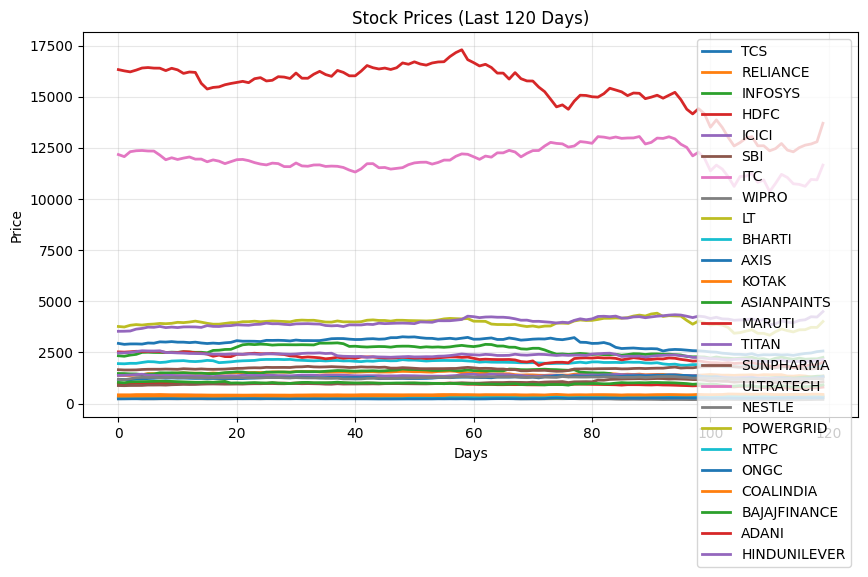


Now enter investment details:

Invalid input. Enter a number.
Invalid input. Enter a number.
Invalid input. Enter a number.
Invalid input. Enter a number.


In [ ]:
# !pip install yfinance

import yfinance as yf
import random
import math
import matplotlib.pyplot as plt

# -----------------------------
# Fixed Stocks (NO USER INPUT)
# -----------------------------
symbols = {
    "TCS": "TCS.NS",
    "RELIANCE": "RELIANCE.NS",
    "INFOSYS": "INFY.NS",
    "HDFC": "HDFCBANK.NS",
    "ICICI": "ICICIBANK.NS",

    "SBI": "SBIN.NS",
    "ITC": "ITC.NS",
    "WIPRO": "WIPRO.NS",
    "LT": "LT.NS",
    "BHARTI": "BHARTIARTL.NS",

    "AXIS": "AXISBANK.NS",
    "KOTAK": "KOTAKBANK.NS",
    "ASIANPAINTS": "ASIANPAINT.NS",
    "MARUTI": "MARUTI.NS",
    "TITAN": "TITAN.NS",

    "SUNPHARMA": "SUNPHARMA.NS",
    "ULTRATECH": "ULTRACEMCO.NS",
    "NESTLE": "NESTLEIND.NS",
    "POWERGRID": "POWERGRID.NS",
    "NTPC": "NTPC.NS",

    "ONGC": "ONGC.NS",
    "COALINDIA": "COALINDIA.NS",
    "BAJAJFINANCE": "BAJFINANCE.NS",
    "ADANI": "ADANIENT.NS",
    "HINDUNILEVER": "HINDUNILVR.NS"
}

# -----------------------------
# Get 120 days real data
# -----------------------------
def get_stock_data(symbol):
    stock = yf.Ticker(symbol)
    hist = stock.history(period="120d")
    return hist['Close'].tolist()

stocks = {}

for name, symbol in symbols.items():
    data = get_stock_data(symbol)
    stocks[name] = data

# -----------------------------
# Plot REAL data (0–120 days)
# -----------------------------
plt.figure(figsize=(10,5))

for name, data in stocks.items():
    plt.plot(data, linewidth=2, label=name)

plt.title("Stock Prices (Last 120 Days)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# -----------------------------
# User Inputs
# -----------------------------

print("\nNow enter investment details:\n")

# Take input safely
while True:
    try:
        shares = int(input("Enter number of shares: "))
        break
    except:
        print("Invalid input. Enter a number.")

while True:
    try:
        invest_days = int(input("Enter number of days to invest AFTER day 120: "))
        if invest_days > 0:
            break
        else:
            print("Enter a positive number.")
    except:
        print("Invalid input.")

# -----------------------------
# Simulate future
# -----------------------------
def simulate_future(data, days):
    future = []
    last_price = data[-1]

    for _ in range(days):
        change = random.uniform(-2, 2)
        last_price = last_price * (1 + change / 100)
        future.append(round(last_price, 2))

    return future

future_data = {}

for name, data in stocks.items():
    future_data[name] = simulate_future(data, invest_days)

# -----------------------------
# Combined Graph (Past + Future)
# -----------------------------
plt.figure(figsize=(12,6))

for name, data in stocks.items():
    future = future_data[name]

    past_days = list(range(len(data)))
    future_days = list(range(len(data), len(data)+invest_days))

    # Past (real)
    plt.plot(past_days, data, linewidth=2, label=f"{name} (Past)")

    # Future (simulated)
    plt.plot(future_days, future, linestyle='--', linewidth=2, label=f"{name} (Future)")

# Investment line
plt.axvline(x=119, linestyle=':', linewidth=2)
plt.text(119, plt.ylim()[1]*0.9, "Investment Point", rotation=90)

plt.title("Stock Trends (Real + Simulated Future)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# -----------------------------
# Overall Analysis
# -----------------------------
print("\n--- Overall Stock Analysis ---\n")

results = {}

for name in stocks:
    start = stocks[name][-1]          # price at day 120
    end = future_data[name][-1]       # final simulated price

    percent = ((end - start) / start) * 100
    results[name] = percent

    print(f"{name}: {percent:.2f}% return")

best_stock = max(results, key=results.get)
worst_stock = min(results, key=results.get)

print(f"\n👉 Best performing stock: {best_stock}")
print(f"👉 Worst performing stock: {worst_stock}")

# -----------------------------
# Investment Analysis (ALL stocks)
# -----------------------------
print("\n--- Investment Analysis ---\n")

for name in stocks:
    buy = stocks[name][-1]
    sell = future_data[name][-1]

    profit = (sell - buy) * shares
    percent = ((sell - buy) / buy) * 100

    print(f"{name}: Profit = {profit:.2f}, Return = {percent:.2f}%")

print(f"\n👉 If you invested in the best stock ({best_stock}), you would get highest return.")

# -----------------------------
# Extra Metric
# -----------------------------
names = list(stocks.keys())

dist = math.sqrt(sum(
    (stocks[names[0]][i] - stocks[names[1]][i])**2
    for i in range(len(stocks[names[0]]))
))

print(f"\nEuclidean Distance between {names[0]} and {names[1]}: {dist:.2f}")

Dropdown(description='Invest 1:', index=2, options=('RELIANCE', 'INFOSYS', 'SBI', 'TCS'), value='SBI')

Dropdown(description='Invest 2:', index=1, options=('RELIANCE', 'INFOSYS', 'SBI', 'TCS'), value='INFOSYS')

IntText(value=100, description='Shares:')

IntText(value=100, description='Future Days:')

Button(button_style='success', description='Run Investment Analysis', style=ButtonStyle())

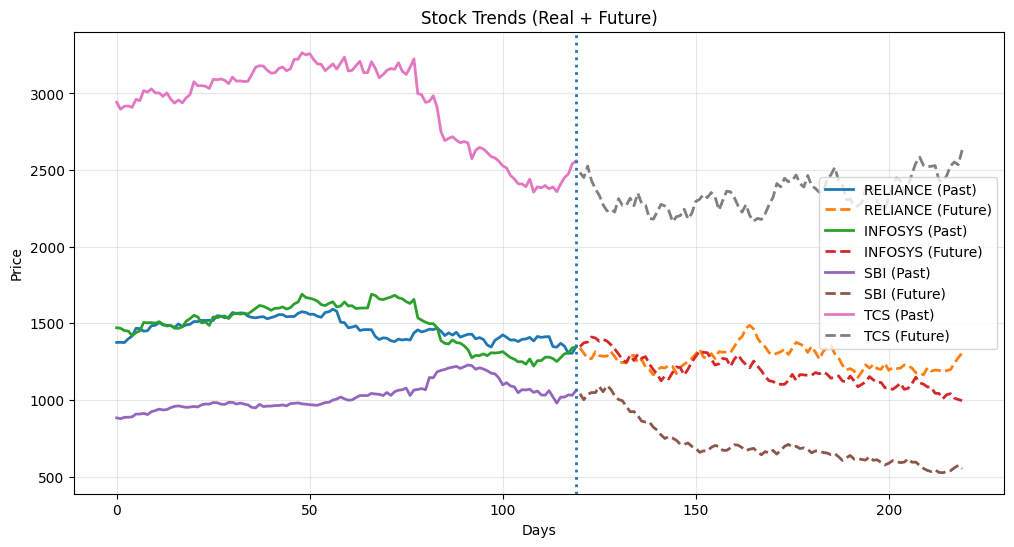


--- Overall Stock Analysis ---

RELIANCE: -3.04% return
INFOSYS: -26.08% return
SBI: -48.06% return
TCS: 2.79% return

👉 Best performing stock: TCS
👉 Worst performing stock: SBI

--- Your Investment Analysis ---

SBI: Profit = -51010.00, Return = -48.06%
INFOSYS: Profit = -35113.00, Return = -26.08%

--- Decision Evaluation ---

Stock Ranking:
1. TCS (2.79%)
2. RELIANCE (-3.04%)
3. INFOSYS (-26.08%)
4. SBI (-48.06%)

👉 Best possible stock: TCS

⚠️ You missed the best stock (TCS).
👉 Better choice would have been: TCS

👉 Between your picks, INFOSYS performed better.

Similarity Score between SBI and INFOSYS: 50.73 / 100
👉 Some similarity


In [ ]:
import yfinance as yf
import random
import math
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==============================
# STOCK LIST
# ==============================
symbols = {
    "TCS": "TCS.NS", "RELIANCE": "RELIANCE.NS", "INFOSYS": "INFY.NS",
    "HDFC": "HDFCBANK.NS", "ICICI": "ICICIBANK.NS",
    "SBI": "SBIN.NS", "ITC": "ITC.NS", "WIPRO": "WIPRO.NS",
    "LT": "LT.NS", "BHARTI": "BHARTIARTL.NS",
    "AXIS": "AXISBANK.NS", "KOTAK": "KOTAKBANK.NS",
    "ASIANPAINTS": "ASIANPAINT.NS", "MARUTI": "MARUTI.NS",
    "TITAN": "TITAN.NS",
    "SUNPHARMA": "SUNPHARMA.NS", "ULTRATECH": "ULTRACEMCO.NS",
    "NESTLE": "NESTLEIND.NS", "POWERGRID": "POWERGRID.NS",
    "NTPC": "NTPC.NS",
    "ONGC": "ONGC.NS", "COALINDIA": "COALINDIA.NS",
    "BAJAJFINANCE": "BAJFINANCE.NS", "ADANI": "ADANIENT.NS",
    "HINDUNILEVER": "HINDUNILVR.NS"
}

options = list(symbols.keys())

# ==============================
# STEP 1: SELECT 4 STOCKS
# ==============================
d1 = widgets.Dropdown(options=options, description='Stock 1:')
d2 = widgets.Dropdown(options=options, description='Stock 2:')
d3 = widgets.Dropdown(options=options, description='Stock 3:')
d4 = widgets.Dropdown(options=options, description='Stock 4:')

btn1 = widgets.Button(description="Load Stocks", button_style='info')

display(d1, d2, d3, d4, btn1)

# ==============================
# FUNCTIONS
# ==============================
def get_stock_data(symbol):
    stock = yf.Ticker(symbol)
    hist = stock.history(period="120d")
    return hist['Close'].tolist()

def simulate_future(data, days):
    future = []
    last_price = data[-1]
    for _ in range(days):
        change = random.uniform(-4, 4)
        last_price = last_price * (1 + change / 100)
        future.append(round(last_price, 2))
    return future

# ==============================
# STEP 1 HANDLER
# ==============================
def load_stocks(b):
    clear_output(wait=True)

    selected4 = [d1.value, d2.value, d3.value, d4.value]

    print("Fetching data...\n")

    stocks = {}
    for name in selected4:
        stocks[name] = get_stock_data(symbols[name])

    # -------- GRAPH 1 --------
    plt.figure(figsize=(10,5))
    for name, data in stocks.items():
        plt.plot(data, linewidth=2, label=name)

    plt.title("Stock Prices (Last 120 Days)")
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print("\nNow choose 2 stocks to invest:\n")

    # ==============================
    # STEP 2 UI (ONLY FROM SELECTED 4)
    # ==============================
    invest_options = selected4

    s1 = widgets.Dropdown(options=invest_options, description='Invest 1:')
    s2 = widgets.Dropdown(options=invest_options, description='Invest 2:')

    shares = widgets.IntText(value=100, description='Shares:')
    days = widgets.IntText(value=30, description='Future Days:')

    btn2 = widgets.Button(description="Run Investment Analysis", button_style='success')

    display(s1, s2, shares, days, btn2)

    # ==============================
    # STEP 2 HANDLER
    # ==============================
    def run_analysis(b2):
        clear_output(wait=True)

        display(s1, s2, shares, days, btn2)

        invest_days = days.value
        num_shares = shares.value

        # -------- GRAPH 2 --------
        plt.figure(figsize=(12,6))

        future_data = {}

        for name, data in stocks.items():
            future = simulate_future(data, invest_days)
            future_data[name] = future

            past_days = list(range(len(data)))
            future_days = list(range(len(data), len(data)+invest_days))

            plt.plot(past_days, data, linewidth=2, label=f"{name} (Past)")
            plt.plot(future_days, future, linestyle='--', linewidth=2, label=f"{name} (Future)")

        plt.axvline(x=119, linestyle=':', linewidth=2)
        plt.title("Stock Trends (Real + Future)")
        plt.xlabel("Days")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        # -------- OVERALL ANALYSIS --------
        print("\n--- Overall Stock Analysis ---\n")

        results = {}
        for name in stocks:
            start = stocks[name][-1]
            end = future_data[name][-1]
            percent = ((end - start) / start) * 100
            results[name] = percent
            print(f"{name}: {percent:.2f}% return")

        best = max(results, key=results.get)
        worst = min(results, key=results.get)

        print(f"\n👉 Best performing stock: {best}")
        print(f"👉 Worst performing stock: {worst}")

        # -------- INVESTMENT ANALYSIS (ONLY 2) --------
        print("\n--- Your Investment Analysis ---\n")

        selected = [s1.value, s2.value]

        # Show chosen stocks performance
        for name in selected:
            buy = stocks[name][-1]
            sell = future_data[name][-1]

            profit = (sell - buy) * num_shares
            percent = ((sell - buy) / buy) * 100

            print(f"{name}: Profit = {profit:.2f}, Return = {percent:.2f}%")

        # -----------------------------
        # Compare with ALL 4 stocks
        # -----------------------------
        print("\n--- Decision Evaluation ---\n")

        # Best overall stock
        best_stock = max(results, key=results.get)

        # Rank all stocks
        sorted_stocks = sorted(results.items(), key=lambda x: x[1], reverse=True)

        print("Stock Ranking:")
        for i, (name, val) in enumerate(sorted_stocks, 1):
            print(f"{i}. {name} ({val:.2f}%)")

        print(f"\n👉 Best possible stock: {best_stock}")

        # -----------------------------
        # Smart Feedback
        # -----------------------------
        if best_stock in selected:
            print(f"\n✅ Good decision! You selected {best_stock}, which was the best performer.")
        else:
            print(f"\n⚠️ You missed the best stock ({best_stock}).")

            # Suggest better choice
            print(f"👉 Better choice would have been: {best_stock}")

        # Compare between chosen 2
        if results[selected[0]] > results[selected[1]]:
            print(f"\n👉 Between your picks, {selected[0]} performed better.")
        elif results[selected[1]] > results[selected[0]]:
            print(f"\n👉 Between your picks, {selected[1]} performed better.")
        else:
            print("\n👉 Both your picks performed equally.")

        # -----------------------------
        # NORMALIZED EUCLIDEAN DISTANCE
        # -----------------------------
        def normalize(data):
            min_val = min(data)
            max_val = max(data)

            if max_val == min_val:
                return [0 for _ in data]  # avoid division by zero

            return [(x - min_val) / (max_val - min_val) for x in data]

        # Normalize selected stocks
        norm1 = normalize(stocks[s1.value])
        norm2 = normalize(stocks[s2.value])

        # Compute distance
        distance = math.sqrt(sum((a - b) ** 2 for a, b in zip(norm1, norm2)))

        # Max possible distance (worst case)
        max_distance = math.sqrt(len(norm1))  # since values in [0,1]

        # Convert to similarity score
        score = (1 - (distance / max_distance)) * 100

        # Clamp score between 0 and 100
        score = max(0, min(100, score))

        print(f"\nSimilarity Score between {s1.value} and {s2.value}: {score:.2f} / 100")

        # Interpretation
        if score > 80:
            print("👉 Very similar trends")
        elif score > 60:
            print("👉 Moderately similar trends")
        elif score > 40:
            print("👉 Some similarity")
        else:
            print("👉 Very different behavior")

    btn2.on_click(run_analysis)

btn1.on_click(load_stocks)